# Уранение теплопроводности 
$$
(x,t) \in (0, l) \times (0, T) \\
u_t = a^2 \Delta u \\
u|_{t=0} = u_0 \\
u(0, t) = u(l, t) = 0
$$

## Разностная явная схема
![image.png](./явная_схема.png)  $\\$
$x_i = ih$ - шаг по $x$ $\\$
$t_j = j\tau$ - шаг по $t$

$$
\frac{u^{j+1}_i-u^j_i}{\tau} = a^2\frac{u^{j}_{i-1}-2u^j_i+u^{j+1}_i}{h^2} \\
$$


$$
u^{j+1}_i = D (u^{j}_{i-1}-2u^j_i+u^{j+1}_i) + u^j_i
$$
где $D= \frac{a^2 \tau}{h^2}$

Условие Куранта 
$$
\tau \leq \frac{h^2}{2a^2}
$$

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dst, idst

def u_0(x, L):
    return x**2 * (L - x)


In [179]:
def explicit_heat_equation(x_limit, h, T, a):
    
    tau = h**2 / (2 * a**2)
     
    x_step = int((x_limit[1] - x_limit[0])/h) + 1
    t_step = int((T[1] - T[0])/tau) + 1
    
    u = np.zeros((t_step, x_step))
    D  = a**2*tau/h**2
    
    x = np.linspace(x_limit[0], x_limit[1], x_step)
    t = np.linspace(T[0], T[1], t_step)
    
    u[0, :] = u_0(x, x_limit[1])
    
    for j in range(t_step - 1):
        for i in range(1, x_step - 1):
            u[j+1, i] = D * (u[j, i-1] - 2*u[j, i] + u[j, i+1]) + u[j, i]
    
    return x, t, u[-1, :]

In [180]:
def get_dn_spectrum(u_T):
    u_inner = u_T[1:-1]
    d_n = dst(u_inner, type=1)
    return d_n

In [181]:
def restore_u0_from_spectrum(d_n, alpha, a, T_final, L):
    Nx_inner = len(d_n)
    Nx = Nx_inner + 2
    
    # Собственные значения (n от 1 до Nx-2)
    n_arr = np.arange(1, Nx - 1)
    lambda_n = (n_arr * np.pi / L)**2
    
    exponent = lambda_n * a**2 * T_final
    
    # Шаг 3: Восстановление c_n (с регуляризацией Тихонова)
    if alpha == 0:
        safe_exponent = np.clip(exponent, a_min=None, a_max=700)
        c_n = d_n * np.exp(safe_exponent)
    else:
        # Алгебраически преобразованная формула для защиты от переполнения (OverflowError)
        c_n = d_n / (np.exp(-exponent) + alpha * np.exp(exponent))
        
    # Шаг 4: Обратное преобразование (IDST)
    u0_inner_restored = idst(c_n, type=1)
    
    # Сборка финального массива с учетом границ
    u0_restored = np.zeros(Nx)
    u0_restored[1:-1] = u0_inner_restored
    return u0_restored

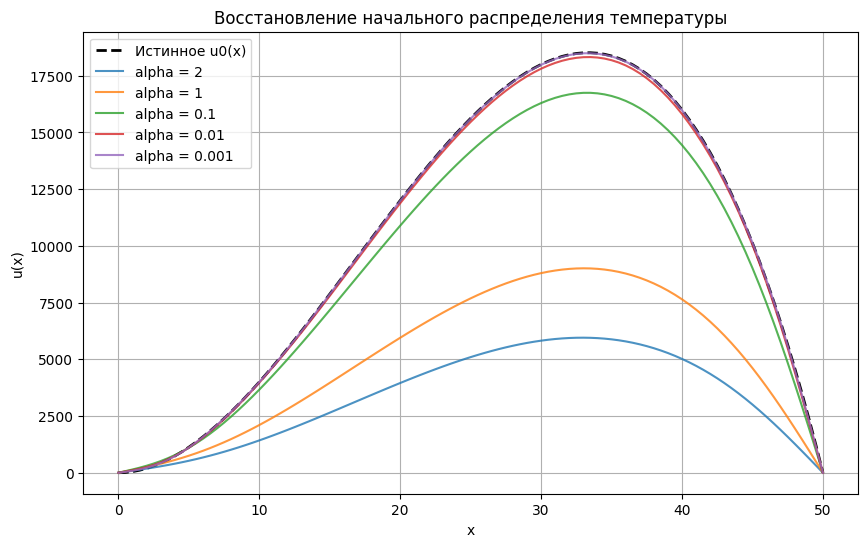

In [188]:
if __name__ == "__main__":
    # Задаем параметры
    L = 50.0
    x_lim = (0.0,  L )
    T_lim = (0.0, 5.0)
    h_step =  L  / 100
    a_coeff = 1.0

    x_vals, t_vals, u_T = explicit_heat_equation(x_lim, h_step, T_lim, a_coeff)
    d_n_spectrum = get_dn_spectrum(u_T)
    
    alphas_to_try = [2, 1, 1e-1, 1e-2, 1e-3]
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_vals, u_0(x_vals,L=L), 'k--', linewidth=2, label='Истинное u0(x)')
    
    
    for alpha in alphas_to_try:
        u0_restored = restore_u0_from_spectrum(
            d_n_spectrum, 
            alpha=alpha, 
            a=a_coeff, 
            T_final=T_lim[1], 
            L=x_lim[1]
        )
        
        label = f'alpha = {alpha}'
        plt.plot(x_vals, u0_restored, label=label, alpha=0.8)

    plt.title('Восстановление начального распределения температуры')
    plt.xlabel('x')
    plt.ylabel('u(x)')
    plt.legend()
    plt.grid(True)
    plt.show()